---
date: last-modified
date-format: "DD MMMM, YYYY"
title: Project Ironman 70.3 - Benchmarks and Goal Setting 
author: Darren Rajit
format: 
    html: 
        echo: false
categories: [General, Personal, Fitness]
link-citations: true
reference-location: margin
cap-location: margin
bibliography: personal.bib
---


So I've been in a bit of a situationship with my fitness for a long time. Grew up chubby, a sore spot I used to hold, though I wouldn't say I was particularly sedentary [^1]. However, it's only been in the past 8 years that I've been *intentional* with how I saw my fitness.

[^1]: Maybe just a bit too keen on my curries and laksas. No regrets.

And so, since 2018, I've made it a point to run a half marathon every year, interspersed with powerlifting style training. Over time, this led me to doing a full marathon last year at the 2023 Sydney Marathon. It was a bit of a dismal showing really, and looking back, my training, commitment, nutrition, and consistency could have been improved [^2].

[^2]: A story for another day, but it was fun and I'd do it again... maybe with a bit more of an injury-free leadup

The problem I've identified is consistency. The general cycle I've noticed is that I would train pretty consistently for an event in the leadup, I'd get sick or life would get in the way and I'd take breaks that would last for up to 2 months. I'd jump back in, get a niggle, and would end up sputtering to the starting line, with not enough miles in my legs. I'd reach the event, finish it, and I'd resolve to not do it again. Then, inevitably, I'd catch the bug again, start training, but always seemingly from the same baseline, and so year-on-year, improvements would come few and far between.

The thing is, I've caught the bug again, and so I find myself wishing complete a full Ironman sometime before I die. I've got plenty of life left to live, but I'd prefer to complete one in a respectable way [^3], within my physical prime. But what does this even mean?

[^3]: Be above average, at the very least.

## Now *This* Is Average Performance

It's obvious that *peak performance* depends on the event you're looking at. Things that require explosive power have a younger peak performance age, relative to things that require endurance, acquired knowledge and/or skill [@stiefel2013]. Then again, there is the added confounder of training age, ie: how long you've been intentionally training over your lifetime. From a purely physiological development perspective though, I do think that there is a inflection point after which things start going downhill. I admit to a certain amount of anxiety when it comes to this, so in that sense, time (and youth) is of the essence.

Thankfully, I've managed to get my grubby hands on a dataset presenting Ironman 70.3 finish times from 2004 up to 2020. 16 years of data! [^4], and it seems that the triathlon bug is hitting, and hitting good. Ironman 70.3 Triathlons are now big business, with 1572 finishers in 2004, up to a peak of 116,196 in 2019 (@fig-finishercount), though I'd attribute the dip in 2020 to Covid.

[^4]: Shoutout to David who painstakingly compiled and cleaned the data available [here](https://www.kaggle.com/datasets/aiaiaidavid/ironman-703-race-data-between-2004-and-2020?resource=download)


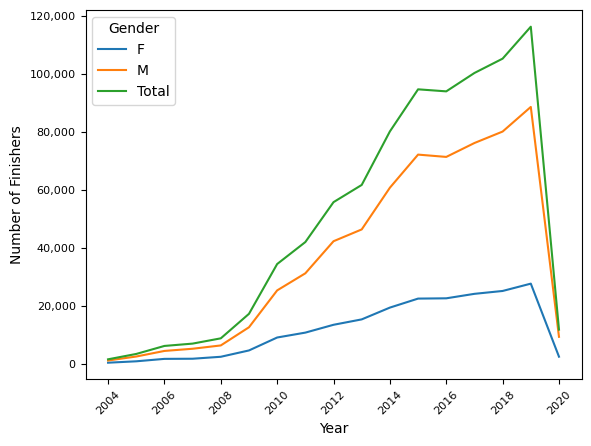

In [1]:
#| fig-cap: 'Finisher counts by year, colored by Gender'
#| label: fig-finishercount
#| echo: false


#standard preprocessing and loading in data 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib as mpl
import warnings 
from scipy.stats import pearsonr, linregress
from IPython.display import Markdown 
from tabulate import tabulate

#setting global tick sizes 
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
warnings.filterwarnings("ignore")

ironman_path = "../datasets/Half_Ironman_df6.csv"
df = pd.read_csv(ironman_path)
df['count'] = 1

#grouping 
finishers_yeargrp = df[['EventYear', 'Gender', 'count']].groupby(['EventYear', 'Gender']).sum().reset_index()
yeargrp = df[['EventYear', 'Gender', 'count']].groupby(['EventYear']).sum().reset_index() 
yeargrp['Gender'] = 'Total'
finishers_yeargrp = pd.concat([finishers_yeargrp, yeargrp]).reset_index(drop=True)

#plotting
finisher_countplt = sns.lineplot(data=finishers_yeargrp, x='EventYear', y='count', hue='Gender')
finisher_countplt.set(xlabel='Year', ylabel='Number of Finishers')
finisher_countplt.get_yaxis().set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.show()

Interestingly, age distributions among **male amateurs of working age** have started to stabilize over the past half decade. Funnily, it seems that doing a triathlon may come hand in hand with having a midlife crisis. Since 2013, almost 40% of finishers have been aged between 35 and 44 (@fig-finisheragedist), with the 18-24 and 60-64 age groups being on the lower end of the working age distribution. Personally, I'd rack this up to the fact that triathlons are both an *expensive* **and** *intensive* sport, probably acessible only to the young uns who can afford it (and have the resources to train for it), and the older ones who've probably had a lifetime worth of training to stand up to the rigous of the sport.


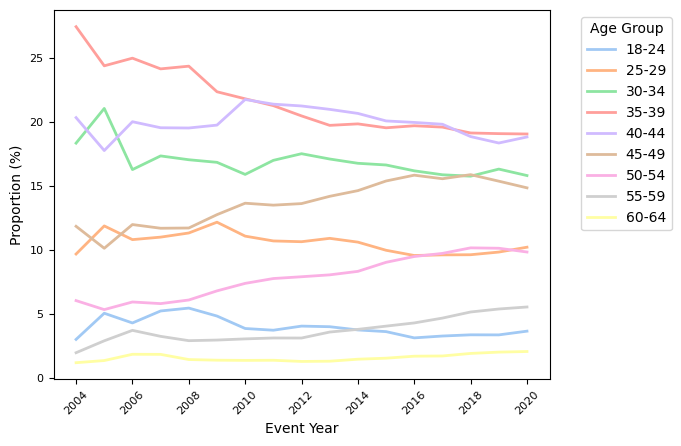

In [2]:
#| fig-cap: 'Age Distribution of Ironman 70.3 Finishers, Male Age Groupers only'
#| label: fig-finisheragedist
#| echo: false

df_men = df[df['Gender']== 'M']
df_amateur = df_men[df_men['AgeGroup'] != '00']
df_pro = df_men[df_men['AgeGroup'] == '00']

time_cols = ['SwimTime', 'BikeTime', 'RunTime', 'FinishTime']
overall_rank_cols = []
yearly_rank_cols = []
for col in time_cols: 
    #assign a percentile rank to each row for each time 
    df_amateur[col + '_overall_rank'] = df_amateur[col].rank(pct=True)*100
    overall_rank_cols.append(col + '_overall_rank')



#set order of age groups 
age_order = ['18-24','25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64']
df_amateur_workingage = df_amateur[df_amateur['AgeGroup'].isin(age_order)]
df_amateur_workingage['AgeGroup'] = pd.Categorical(df_amateur_workingage['AgeGroup'], categories=age_order, ordered=True)
df_amateur_workingage['Performance_category'] = pd.cut(df_amateur_workingage['FinishTime_overall_rank'], bins=[0,5,10,20,35,50,100], labels=['Elite', 'Advanced', 'Intermediate', 'Above Average', 'Average', 'Below Average'])

age_dist_year = df_amateur_workingage[['EventYear', 'AgeGroup', 'count']].groupby(['EventYear', 'AgeGroup']).sum()

#normalize counts and plot distributions 
total_agegroup_counts_year = age_dist_year.groupby('EventYear')['count'].sum().reset_index()
age_dist_year['total'] = (age_dist_year.index.get_level_values('EventYear').map(total_agegroup_counts_year.set_index('EventYear')['count'])).astype(int)
age_dist_year['proportion'] = age_dist_year['count']/age_dist_year['total']*100
age_dist_year.reset_index(inplace=True)
pivot_df = age_dist_year.pivot(index='EventYear', columns='AgeGroup', values='proportion')
#set order of age groups 
age_order = ['18-24','25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64']
palette = sns.color_palette("pastel", len(age_order))
sns.set_palette(palette)

for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker='', linewidth=2, label=column)

plt.xlabel('Event Year')
plt.ylabel('Proportion (%)')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

The thing is, with participation higher than ever before excepting the blip in 2020 (@fig-finishercount), you'd think the overall standard would have increased. Interestingly, not exactly. At first glance, you'd see a raft of improvements from 2004 to 2010, followed by what seems to be a plateau in average (ie: 50th percentile) performance, across all disciplines [^5]. And so it seems w'ere now in the age of slow, marginal level improvements. (@fig-averagefinishtimes) [^6]. We can probably attribute this to the fact that as more people get involved with the Ironman 70.3, a whole initial raft of enthusiasts would have lead to initial improvements over time, but as the late majority joined the sport, what we know see is a gradul regresson to the mean. This seems to be especially the case for us amateurs, but something else seems to be happening with the pros...

[^5]: excepting 2020

[^6]: I assume the sharp improvement in finish times here were due to an exceptionally more dedicated field of athletes, in both the pros and amateurs, possibly due to Covid restrictions meaning that only the more gungho folks would have still tried to participate at an Ironman.


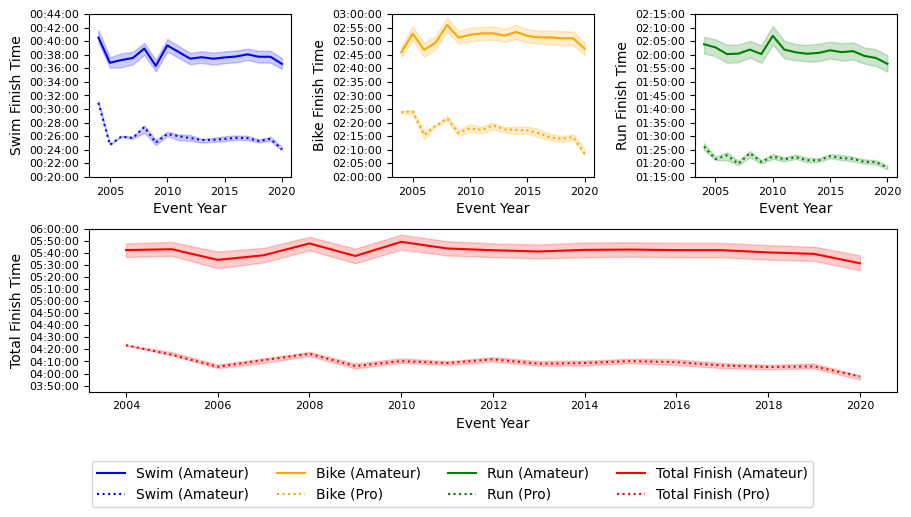

In [3]:
#| fig-cap: 'The average standard (45th - 55th Percentile) when it comes to finish times across the years for Men. Top row: Swim, Bike and Run finish times respectively. Bottom Row: Total Finish times. Dotted lines are the pros, solid lines are us mere mortals.'
#| fig-cap-location: margin
#| label: fig-averagefinishtimes
#| echo: false

df_amateur_yearly_avg = pd.DataFrame(df_amateur['EventYear'].unique()).rename(columns={0:'EventYear'})
for i in range (0,100,5): 
    for col in time_cols: 
        colname = col + '_'+str(100-i)+'_percentile'
        quantile_data = df_amateur.groupby(['EventYear'])[col].quantile(i/100).reset_index()
        #convert to hh:mm:ss format 
        quantile_data.rename(columns={col:colname}, inplace=True)
        df_amateur_yearly_avg = pd.merge(df_amateur_yearly_avg, quantile_data, on='EventYear', how='left')

df_pro_yearly_avg = pd.DataFrame(df_pro['EventYear'].unique()).rename(columns={0:'EventYear'})
for i in range (0,100,5): 
    for col in time_cols: 
        colname = col + '_'+str(100-i)+'_percentile'
        quantile_data = df_pro.groupby(['EventYear'])[col].quantile(i/100).reset_index()
        #convert to hh:mm:ss format 
        quantile_data.rename(columns={col:colname}, inplace=True)
        df_pro_yearly_avg = pd.merge(df_pro_yearly_avg, quantile_data, on='EventYear', how='left')
        
#sort by event year 
df_amateur_yearly_avg = df_amateur_yearly_avg.sort_values(by='EventYear').reset_index(drop=True)
df_pro_yearly_avg = df_pro_yearly_avg.sort_values(by='EventYear').reset_index(drop=True)

def seconds_to_hhmmss(seconds):
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    seconds = seconds % 60
    return f'{int(hours):02}:{int(minutes):02}:{int(seconds):02}'

#plot above average 55th to 69th percentile finish times 
axs = plt.figure(layout = 'constrained', figsize= (9,5)).subplot_mosaic(
    """ABC;DDD"""
    )
#plot above average 55th to 69th percentile finish times

sns.lineplot(data = df_amateur_yearly_avg, x = 'EventYear', y = 'SwimTime_50_percentile', label = 'Swim (Amateur)', color = 'blue', ax=axs['A'])
axs['A'].fill_between(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg['SwimTime_45_percentile'], df_amateur_yearly_avg['SwimTime_55_percentile'], alpha=0.2, color = 'blue')
sns.lineplot(data = df_pro_yearly_avg, x = 'EventYear', y = 'SwimTime_50_percentile', label = 'Swim (Amateur)', linestyle='dotted', color = 'blue', ax = axs['A'])
axs['A'].fill_between(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg['SwimTime_45_percentile'], df_pro_yearly_avg['SwimTime_55_percentile'], alpha=0.2, color = 'blue')

sns.lineplot(data = df_amateur_yearly_avg, x = 'EventYear', y = 'BikeTime_50_percentile', label = 'Bike (Amateur)', color = 'orange', ax = axs['B'])
axs['B'].fill_between(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg['BikeTime_45_percentile'], df_amateur_yearly_avg['BikeTime_55_percentile'], alpha=0.2, color = 'orange')
sns.lineplot(data = df_pro_yearly_avg, x = 'EventYear', y = 'BikeTime_50_percentile', label = 'Bike (Pro)', linestyle='dotted', color = 'orange', ax = axs['B'])
axs['B'].fill_between(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg['BikeTime_45_percentile'], df_pro_yearly_avg['BikeTime_55_percentile'], alpha=0.2, color = 'orange')

sns.lineplot(data = df_amateur_yearly_avg, x = 'EventYear', y = 'RunTime_50_percentile', label = 'Run (Amateur)', color = 'green', ax = axs['C'])
axs['C'].fill_between(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg['RunTime_45_percentile'], df_amateur_yearly_avg['RunTime_55_percentile'], alpha=0.2, color = 'green')
sns.lineplot(data = df_pro_yearly_avg, x = 'EventYear', y = 'RunTime_50_percentile', label = 'Run (Pro)', linestyle='dotted', color = 'green', ax = axs['C'])
axs['C'].fill_between(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg['RunTime_45_percentile'], df_pro_yearly_avg['RunTime_55_percentile'], alpha=0.2, color = 'green')

sns.lineplot(data = df_amateur_yearly_avg, x = 'EventYear', y = 'FinishTime_50_percentile', label = 'Total Finish (Amateur)', color = 'red', ax = axs['D'])
axs['D'].fill_between(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg['FinishTime_45_percentile'], df_amateur_yearly_avg['FinishTime_55_percentile'], alpha=0.2, color = 'red')
sns.lineplot(data = df_pro_yearly_avg, x = 'EventYear', y = 'FinishTime_50_percentile', label = 'Total Finish (Pro)', linestyle='dotted', color = 'red', ax = axs['D'])
axs['D'].fill_between(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg['FinishTime_45_percentile'], df_pro_yearly_avg['FinishTime_55_percentile'], alpha=0.2, color = 'red')

from matplotlib.ticker import FuncFormatter, MultipleLocator
formatter = FuncFormatter(lambda x, _: seconds_to_hhmmss(x))
axs['A'].yaxis.set_major_formatter(formatter)
axs['A'].yaxis.set_major_locator(MultipleLocator(base=120))
axs['A'].set_ylabel('Swim Finish Time')
axs['A'].set_xlabel('Event Year')
axs['A'].set_ylim(1200,2640)
axs['B'].yaxis.set_major_formatter(formatter)
axs['B'].yaxis.set_major_locator(MultipleLocator(base=300))
axs['B'].set_ylabel('Bike Finish Time')
axs['B'].set_xlabel('Event Year')
axs['B'].set_ylim(7200,10800)
axs['C'].yaxis.set_major_formatter(formatter)
axs['C'].yaxis.set_major_locator(MultipleLocator(base=300))
axs['C'].set_ylabel('Run Finish Time')
axs['C'].set_xlabel('Event Year')
axs['C'].set_ylim(4500,8100)
axs['D'].yaxis.set_major_formatter(formatter)
axs['D'].yaxis.set_major_locator(MultipleLocator(base=600))
axs['D'].set_ylim(13500,21600)
axs['D'].set_xlabel('Event Year')
axs['D'].set_ylabel('Total Finish Time')

# # Combine legends from all subplots into one
lines_labels = [ax.get_legend_handles_labels() for ax in plt.gcf().axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
for ax in plt.gcf().axes:
    ax.get_legend().remove()

plt.legend(lines, labels, loc='lower center',ncol=4, bbox_to_anchor=(0.45, -0.75))
plt.show()

In fact, doing some quick correlation analysis (@tbl-finishtimepct_year_corr) of finish times across different performance percentiles vs year indicates a very weak, non-significant negative correlation (ie: faster times) for us amateurs. Essentially, achieving average to elite times as an amateur age grouper has remained virtually unchanged over the years, and the time taken to say, be above average in one year would still make you above average in another. It's a whole different ball game for the professionals though, with finish times being **strongly** correlated with the progression of time, from 2004 to 2020. The standard to go pro has never been harder, and it makes sense with the influx of Olympians into the sport over the past few years, with the Norweigians and their new-fangled approach to training widely hailed as one of the reasons for why World Records in the triathlon have been tumbling.


In [4]:
#| label: tbl-finishtimepct_year_corr
#| tbl-cap: 'Correlation analysis between Event Years, and Total Finish Times at various performance percentiles, pros and amateurs (Male, Aged 18 - 64)'
#| echo: false

finish_percentile_col = ['FinishTime_50_percentile', 'FinishTime_65_percentile', 'FinishTime_80_percentile', 'FinishTime_90_percentile', 'FinishTime_95_percentile']
fin_percentile_naming = ['50th', '65th', '80th', '90th', '95th']

#calculate correlation coefficient for each percentile
df_eventyear_finish_corr = pd.DataFrame()
for i, col in enumerate(finish_percentile_col): 
    pro_corr = pearsonr(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg[col])
    amateur_corr = pearsonr(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg[col])
    # Format p-values
    pro_pvalue = '<0.01' if pro_corr[1] <= 0.01 else float('%.2g' % pro_corr[1])
    amateur_pvalue = '<0.01' if amateur_corr[1] <= 0.01 else float('%.2g' % amateur_corr[1])
    
    # Create a single-row dataframe for current percentile
    result_df = pd.DataFrame({
        'Percentile': [fin_percentile_naming[i]],
        'r, p (Pro)': [f"{float('%.2g' % pro_corr[0])}, {pro_pvalue}"],
        'r, p (Amateur)': [f"{float('%.2g' % amateur_corr[0])}, {amateur_pvalue}"]
    })
    
    df_eventyear_finish_corr = pd.concat([df_eventyear_finish_corr, result_df], axis = 0, ignore_index =True)
    
Markdown(tabulate(df_eventyear_finish_corr, headers = 'keys', tablefmt = 'pipe', showindex=False, numalign = ['right','right','right','right','right']))

| Percentile   | r, p (Pro)   | r, p (Amateur)   |
|:-------------|:-------------|:-----------------|
| 50th         | -0.71, <0.01 | -0.22, 0.39      |
| 65th         | -0.72, <0.01 | -0.17, 0.5       |
| 80th         | -0.74, <0.01 | -0.11, 0.68      |
| 90th         | -0.72, <0.01 | -0.12, 0.66      |
| 95th         | -0.72, <0.01 | -0.2, 0.44       |

But then again, I have no ambitions at the moment for ever becoming elite in any age-group, nor going pro for that matter. However, I don't wish to just *finish*. What this data is telling me then is that we've got some reasonably stable benchmarks (@tbl-finishtimepct_benchmarks) that will hold steady for quite a while yet. Out of all of these, the running benchmarks seem to be the most reasonable. Though keep in mind that running is the last event of the triathlon, so you're going to be running on tired legs, after an average of 2.5 hours of hard cycling. In isolation though, it does *seem* to be in the realm of possibility. 


In [5]:
#| label: tbl-finishtimepct_benchmarks
#| tbl-cap: 'Completely Arbitrary Benchmark Finish Times at various performance percentiles, Amateur Males, Aged 18 - 64)'
#| echo: false

extra_event_list = [] 

for event in ['SwimTime', 'BikeTime', 'RunTime']: 
    for pct in ['50_percentile', '65_percentile', '80_percentile', '90_percentile', '95_percentile']: 
        col_name = event+'_'+pct
        extra_event_list.append(col_name)

finish_percentile_col.extend(extra_event_list)

benchmark_names = ['Average (50th Percentile)', 'Above Average (65th Percentile)', 'Intermediate (80th Percentile)', 'Advanced (90th Percentile)', 'Elite (95th Percentile)']

def seconds_to_hhmmss(seconds):
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    seconds = seconds % 60
    return f'{int(hours):02}:{int(minutes):02}:{int(seconds):02}'

# Calculate mean and standard deviation for each percentile column
df_mean_pct = df_amateur_yearly_avg[finish_percentile_col].mean().round(2)
df_std_pct = df_amateur_yearly_avg[finish_percentile_col].std().round(2)
df_mean_pct = df_mean_pct.apply(lambda x : seconds_to_hhmmss(x))
df_std_pct = df_std_pct.apply(lambda x : seconds_to_hhmmss(x))

# Combine mean and SD into a single string for each column
mean_std_combined = df_mean_pct.astype(str) + " ± " + df_std_pct.astype(str)
mean_std_combined

# Create a DataFrame for the combined mean and SD values
df_mean_std_combined = pd.DataFrame(mean_std_combined, columns=['Mean Finish Times ± SD']).reset_index(drop=True)
df_mean_std_combined['Event_pct'] = finish_percentile_col 
#extract event and percentiles 
df_mean_std_combined[["Event", "Percentile"]] = df_mean_std_combined['Event_pct'].str.extract(r"(.+Time)_(\d+_percentile)")
df_meanstd_pivot = df_mean_std_combined.pivot(index = "Percentile", columns = "Event", values = "Mean Finish Times ± SD").reset_index()

# # Create a DataFrame for benchmark names
df_benchmark_names = pd.DataFrame(benchmark_names, columns=['Benchmark'])

# # Concatenate benchmark names with combined mean and SD values
df_benchmarks = pd.concat([df_benchmark_names, df_meanstd_pivot], axis=1)
df_benchmarks.drop(columns = ['Percentile'], inplace = True)

# # Use tabulate to create a markdown table from the DataFrame
markdown_table = tabulate(df_benchmarks, headers='keys', tablefmt='pipe', showindex=False)
Markdown(markdown_table)

| Benchmark                       | BikeTime            | FinishTime          | RunTime             | SwimTime            |
|:--------------------------------|:--------------------|:--------------------|:--------------------|:--------------------|
| Average (50th Percentile)       | 02:51:08 ± 00:02:33 | 05:41:03 ± 00:04:19 | 02:01:06 ± 00:02:10 | 00:37:49 ± 00:01:01 |
| Above Average (65th Percentile) | 02:43:53 ± 00:02:31 | 05:23:15 ± 00:04:46 | 01:52:07 ± 00:01:50 | 00:35:15 ± 00:00:57 |
| Intermediate (80th Percentile)  | 02:36:06 ± 00:02:36 | 05:04:05 ± 00:05:03 | 01:43:09 ± 00:01:40 | 00:32:28 ± 00:00:55 |
| Advanced (90th Percentile)      | 02:29:26 ± 00:02:53 | 04:48:30 ± 00:04:53 | 01:36:04 ± 00:01:24 | 00:29:58 ± 00:00:53 |
| Elite (95th Percentile)         | 02:24:36 ± 00:03:18 | 04:37:28 ± 00:04:52 | 01:31:13 ± 00:01:21 | 00:28:06 ± 00:00:56 |

## Age Groups and Performance, How Long Do I Have At My Theoretical Peak?

Alright, we now know what seems to be a reasonable enough time to finish an Ironman 70.3. But does age matter at all? Do i have all the time in the world to train for this if my goal is to just be above average? 


In [16]:
df_amateur_workingage

#plot boxplot of finish times across different age groups 

#| fig-cap: 'Boxplot of Finish Times across different Age Groups" 

df_age_percentile = pd.crosstab(df_amateur_workingage['AgeGroup'], df_amateur_workingage['Performance_category'])
df_age_percentile_norm = df_age_percentile.div(df_age_percentile.sum(axis=1), axis = 0)*100
df_age_percentile_norm

Performance_category,Elite,Sub-Elite,Above Average,Average,Below Average
AgeGroup,,,,,
18-24,10.434086,18.119552,19.267034,17.657001,34.522327
25-29,8.799708,17.179402,19.404688,18.569413,36.046788
30-34,7.445631,17.268695,20.315881,19.088977,35.880815
35-39,5.708443,16.687276,20.682298,19.773861,37.148122
40-44,4.025586,15.234637,20.851697,20.584025,39.304054
45-49,2.886850,13.730640,20.400333,21.204457,41.777720
50-54,1.648175,11.583751,19.735147,21.458482,45.574445
55-59,0.510436,8.178312,17.834997,20.954325,52.521930
60-64,0.174216,3.813395,13.830817,20.963995,61.217576


In [6]:
# calculate correlation coefficient for each percentile
df_agegroup_finish_corr = pd.DataFrame()
for i, col in enumerate(finish_percentile_col): 
    amateur_corr = pearsonr(df_amateur_yearly_avg['AgeGroup'], df_amateur_yearly_avg[col])
    # Format p-values
    amateur_pvalue = '<0.01' if amateur_corr[1] <= 0.01 else float('%.2g' % amateur_corr[1])
    
    # Create a single-row dataframe for current percentile
    result_df = pd.DataFrame({
        'Percentile': [fin_percentile_naming[i]],
        'r, p (Amateur)': [f"{float('%.2g' % amateur_corr[0])}, {amateur_pvalue}"]
    })
    
    df_eventyear_finish_corr = pd.concat([df_eventyear_finish_corr, result_df], axis = 0, ignore_index =True)
    
Markdown(tabulate(df_eventyear_finish_corr, headers = 'keys', tablefmt = 'pipe', showindex=False, numalign = ['right','right','right','right','right']))


KeyError: 'AgeGroup'

## My Current Baseline

As of writing (12th June 2024), I am 29 years old, and stand at 174 cm (5'9") at a slightly tubby 77kg.

Endurance